### 1. Imports and data

In [2]:
%pip install --upgrade keras
import numpy as np
from tensorflow.keras.datasets import mnist

# Load MNIST from Keras (downloads automatically if needed)
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Use only the first 1000 examples to keep training fast in a notebook
train_images = train_images[:1000]
train_labels = train_labels[:1000]
test_images  = test_images[:1000]
test_labels  = test_labels[:1000]

print("Train:", train_images.shape, train_labels.shape)
print("Test: ", test_images.shape, test_labels.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (1000, 28, 28) (1000,)
Test:  (1000, 28, 28) (1000,)


We import NumPy for math and Keras' MNIST loader.

MNIST gives us 28×28 grayscale images of digits (0–9).

We limit training/testing to only 1000 samples each so training is fast.

The shapes printed help us confirm the data loaded correctly.

### 2. Conv layer (3×3 filters, single-channel input)

In [3]:
class Conv3x3:
    """
    A simple 3x3 convolution layer for single-channel (grayscale) images.

    Input shape:  (H, W)
    Output shape: (H - 2, W - 2, num_filters)
    """

    def __init__(self, num_filters: int):
        self.num_filters = num_filters
        # filters shape: (num_filters, 3, 3)
        # Divide by 9 to reduce variance (simple scaling)
        self.filters = np.random.randn(num_filters, 3, 3) / 9.0

    def iterate_regions(self, image):
        """
        Slide a 3x3 window over the image.
        Yields (region, i, j), where region is a 3x3 patch and (i,j) is its top-left in output.
        """
        h, w = image.shape
        for i in range(h - 2):
            for j in range(w - 2):
                region = image[i:i+3, j:j+3]
                yield region, i, j

    def forward(self, x):
        """
        x: (H, W)
        returns: (H - 2, W - 2, num_filters)
        """
        self.last_input = x

        h, w = x.shape
        out = np.zeros((h - 2, w - 2, self.num_filters))

        # For each 3x3 region, compute convolution with each filter
        for region, i, j in self.iterate_regions(x):
            # region shape: (3, 3)
            # filters shape: (num_filters, 3, 3)
            # region * filters → (num_filters, 3, 3)
            # sum over (1,2) → (num_filters,)
            out[i, j] = np.sum(region * self.filters, axis=(1, 2))

        return out

    def backward(self, d_out, lr: float):
        """
        d_out: gradient of loss w.r.t. layer output, shape (H - 2, W - 2, num_filters)
        lr:   learning rate

        We compute gradients w.r.t filters and update them.
        This layer is the first one, so we do not propagate back to the image.
        """
        d_filters = np.zeros_like(self.filters)

        # Accumulate gradient for each filter
        for region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                # dL/d(filter[f]) += dL/d_out[i,j,f] * region
                d_filters[f] += d_out[i, j, f] * region

        # Gradient descent step
        self.filters -= lr * d_filters

        # No gradient to pass further back (we stop at the input image)
        return None


This layer contains 3×3 filters that slide over the image.

Each filter detects simple patterns (edges, corners, textures).

iterate_regions gives us each 3×3 patch in the image.

forward multiplies each patch with each filter → creates a feature map.

Output becomes smaller because no padding is used.

In backward, we compute how each filter contributed to the loss and update it.

### 3. ReLU layer

In [4]:
class ReLU:
    """
    ReLU activation: y = max(0, x)
    Applied elementwise.
    """

    def forward(self, x):
        self.last_input = x
        return np.maximum(0, x)

    def backward(self, d_out):
        """
        d_out: gradient from above, same shape as x
        We zero out gradients where input was <= 0.
        """
        d_x = d_out.copy()
        d_x[self.last_input <= 0] = 0
        return d_x


ReLU sets all negative values to zero.

This makes the network non-linear, letting it learn more complex features.

Backprop passes gradient only where the original input was positive.

### 4. MaxPool 2×2 layer

In [5]:
class MaxPool2:
    """
    2x2 max pooling with stride 2.

    Input shape:  (H, W, C)
    Output shape: (H/2, W/2, C)
    """

    def iterate_regions(self, image):
        """
        image: (H, W, C)
        Yields (region, i, j) where region is (2,2,C) and (i,j) is index in output.
        """
        h, w, c = image.shape
        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):
                region = image[i*2:i*2+2, j*2:j*2+2]
                yield region, i, j

    def forward(self, x):
        """
        x: (H, W, C)
        returns: (H/2, W/2, C)
        """
        self.last_input = x

        h, w, c = x.shape
        out = np.zeros((h // 2, w // 2, c))

        for region, i, j in self.iterate_regions(x):
            # Take max over 2x2 region for each channel
            out[i, j] = np.max(region, axis=(0, 1))

        return out

    def backward(self, d_out):
        """
        d_out: gradient of loss w.r.t. output, shape (H/2, W/2, C)

        We route the gradient back only to the max positions.
        """
        h, w, c = self.last_input.shape
        d_x = np.zeros_like(self.last_input)

        for region, i, j in self.iterate_regions(self.last_input):
            region_h, region_w, region_c = region.shape
            max_vals = np.max(region, axis=(0, 1))

            for i2 in range(region_h):
                for j2 in range(region_w):
                    for f in range(region_c):
                        # If this position was the max, it gets the gradient
                        if region[i2, j2, f] == max_vals[f]:
                            d_x[i*2 + i2, j*2 + j2, f] = d_out[i, j, f]

        return d_x


Pooling reduces image size by half → makes computations smaller & faster.

Only the maximum value is kept from each 2×2 block.

During backprop, the gradient is passed only to the maximum location.

### 5. Softmax + cross-entropy as one layer

In [6]:
class Softmax:
    """
    Fully connected layer + softmax + cross-entropy.

    Input:  flattened vector of length input_len
    Output: probabilities over num_classes
    """

    def __init__(self, input_len: int, num_classes: int):
        # weights: (input_len, num_classes)
        self.weights = np.random.randn(input_len, num_classes) / input_len
        self.biases = np.zeros(num_classes)

    def forward(self, x, label):
        """
        x:      input tensor (e.g. from pooling), any shape
        label:  integer class label (0..num_classes-1)

        Returns: (probs, loss, acc)
        """
        # Save original shape to reshape gradient later
        self.last_input_shape = x.shape

        # Flatten to vector
        x_flat = x.flatten()
        self.last_input = x_flat

        # Linear layer: logits = xW + b
        logits = x_flat @ self.weights + self.biases
        self.last_logits = logits

        # Softmax (with numerical stability)
        logits_shifted = logits - np.max(logits)
        exp = np.exp(logits_shifted)
        probs = exp / np.sum(exp)
        self.last_probs = probs

        # Cross-entropy loss
        loss = -np.log(probs[label])
        acc = 1 if np.argmax(probs) == label else 0

        return probs, loss, acc

    def backward(self, label, lr: float):
        """
        Backprop through softmax + cross-entropy + linear layer.

        label: true class index
        lr:    learning rate

        Returns gradient w.r.t. input x (reshaped to original).
        """
        # Gradient of loss w.r.t. logits:
        # dL/dz = probs - one_hot(label)
        d_logits = self.last_probs.copy()
        d_logits[label] -= 1   # (num_classes,)

        # Gradients for weights and biases
        # weights: (input_len, num_classes)
        # last_input: (input_len,)
        dW = np.outer(self.last_input, d_logits)   # (input_len, num_classes)
        db = d_logits                              # (num_classes,)

        # Gradient w.r.t. input x (flattened)
        d_input_flat = self.weights @ d_logits     # (input_len,)

        # Gradient descent update
        self.weights -= lr * dW
        self.biases  -= lr * db

        # Reshape gradient back to input shape
        return d_input_flat.reshape(self.last_input_shape)


This layer converts the final feature map into a 10-class probability vector.

Softmax makes numbers behave like probabilities (sum to 1).

Cross-entropy loss becomes: −log(𝑝correct)

Backprop uses the classic formula:
    gradient = predicted_probs − one_hot(label)

### 6. Putting the model together

In [7]:
# Create layers
conv    = Conv3x3(num_filters=8)
relu    = ReLU()
pool    = MaxPool2()
softmax = Softmax(input_len=13 * 13 * 8, num_classes=10)

def forward(image, label):
    """
    One full forward pass through the network.
    image: (28, 28), pixel values 0..255
    label: integer in [0..9]

    Returns: (probs, loss, acc)
    """
    # Normalize image to roughly [-0.5, 0.5]
    x = (image / 255.0) - 0.5           # shape: (28, 28)

    x = conv.forward(x)                 # (26, 26, 8)
    x = relu.forward(x)                 # (26, 26, 8)
    x = pool.forward(x)                 # (13, 13, 8)
    probs, loss, acc = softmax.forward(x, label)  # (10,)

    return probs, loss, acc

def train_step(image, label, lr=0.005):
    """
    Run forward + backward on a single (image, label).
    Returns: (loss, acc)
    """
    # Forward pass
    _, loss, acc = forward(image, label)

    # Backward pass
    # Start from softmax (it knows the label)
    grad = softmax.backward(label, lr)  # gradient w.r.t. pool output
    grad = pool.backward(grad)          # gradient w.r.t. relu output
    grad = relu.backward(grad)          # gradient w.r.t. conv output
    conv.backward(grad, lr)             # update conv filters

    return loss, acc


Input: 28×28 image

Conv3x3 (8 filters) → 26×26×8

ReLU → 26×26×8

MaxPool2×2 → 13×13×8

Softmax FC → 10 classes

Forward pass: image flows through all layers to get prediction.

Backward pass: gradients flow in reverse order to update weights.

Every layer only needs to understand its own forward/backward logic.

### 7. Training loop

In [8]:
print("MNIST CNN (from scratch) initialized!")

num_epochs = 3
learning_rate = 0.005

for epoch in range(num_epochs):
    print(f"\n--- Epoch {epoch + 1} ---")

    # Shuffle training data
    permutation = np.random.permutation(len(train_images))
    train_images = train_images[permutation]
    train_labels = train_labels[permutation]

    total_loss = 0.0
    num_correct = 0

    for i, (image, label) in enumerate(zip(train_images, train_labels), start=1):
        loss, acc = train_step(image, label, lr=learning_rate)
        total_loss += loss
        num_correct += acc

        if i % 100 == 0:
            avg_loss = total_loss / 100
            accuracy = num_correct
            print(f"[Step {i}] Avg Loss: {avg_loss:.3f} | Correct: {accuracy}/100")
            total_loss = 0.0
            num_correct = 0


MNIST CNN (from scratch) initialized!

--- Epoch 1 ---
[Step 100] Avg Loss: 2.329 | Correct: 11/100
[Step 200] Avg Loss: 2.251 | Correct: 23/100
[Step 300] Avg Loss: 2.205 | Correct: 25/100
[Step 400] Avg Loss: 2.097 | Correct: 37/100
[Step 500] Avg Loss: 2.022 | Correct: 29/100
[Step 600] Avg Loss: 1.783 | Correct: 47/100
[Step 700] Avg Loss: 1.582 | Correct: 48/100
[Step 800] Avg Loss: 1.330 | Correct: 61/100
[Step 900] Avg Loss: 1.179 | Correct: 66/100
[Step 1000] Avg Loss: 1.053 | Correct: 63/100

--- Epoch 2 ---
[Step 100] Avg Loss: 0.850 | Correct: 77/100
[Step 200] Avg Loss: 0.870 | Correct: 71/100
[Step 300] Avg Loss: 0.603 | Correct: 82/100
[Step 400] Avg Loss: 0.700 | Correct: 80/100
[Step 500] Avg Loss: 0.647 | Correct: 80/100
[Step 600] Avg Loss: 0.746 | Correct: 78/100
[Step 700] Avg Loss: 0.610 | Correct: 86/100
[Step 800] Avg Loss: 0.655 | Correct: 78/100
[Step 900] Avg Loss: 0.406 | Correct: 90/100
[Step 1000] Avg Loss: 0.540 | Correct: 88/100

--- Epoch 3 ---
[Step 100

The data is shuffled each epoch.

Every 100 images we print:

    the average loss

    how many predictions were correct

This gives a sense of how training is improving.

### 8. Testing

In [9]:
print("\n--- Testing the CNN ---")
total_loss = 0.0
num_correct = 0

for image, label in zip(test_images, test_labels):
    _, loss, acc = forward(image, label)
    total_loss += loss
    num_correct += acc

num_tests = len(test_images)
print("Test Loss:    ", total_loss / num_tests)
print("Test Accuracy:", num_correct / num_tests)



--- Testing the CNN ---
Test Loss:     0.5313848492148666
Test Accuracy: 0.823


Testing uses forward only, no training.

Shows how well the network generalizes to data it has never seen.

### 9. Visualization

Visualize learned Conv filters

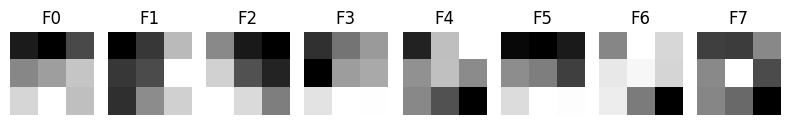

In [13]:
import matplotlib.pyplot as plt

def show_conv_filters(conv_layer):
    num_filters = conv_layer.num_filters
    plt.figure(figsize=(8, 2))
    for i in range(num_filters):
        plt.subplot(1, num_filters, i+1)
        plt.imshow(conv_layer.filters[i], cmap="gray")
        plt.title(f"F{i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_conv_filters(conv)


Visualize feature maps (Conv → ReLU → Pool) for a single image

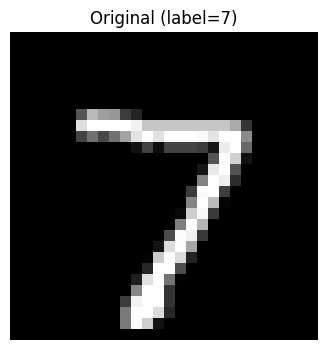

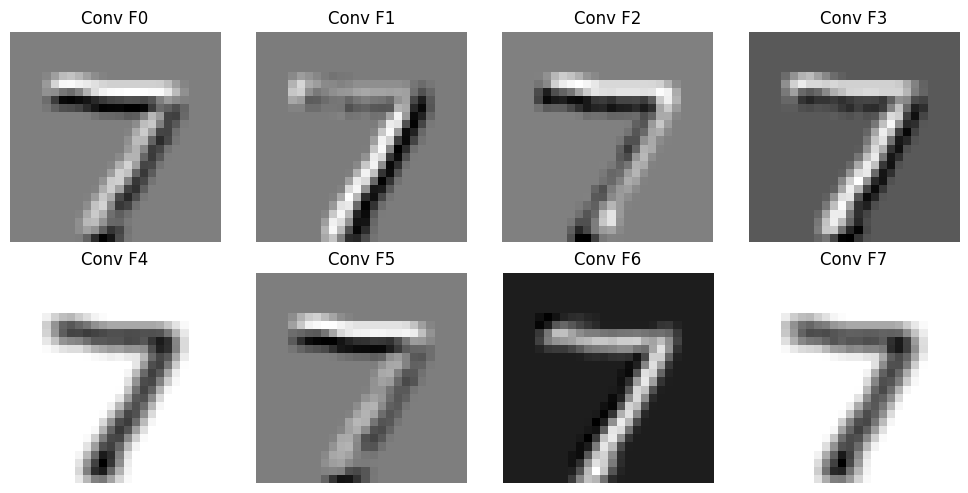

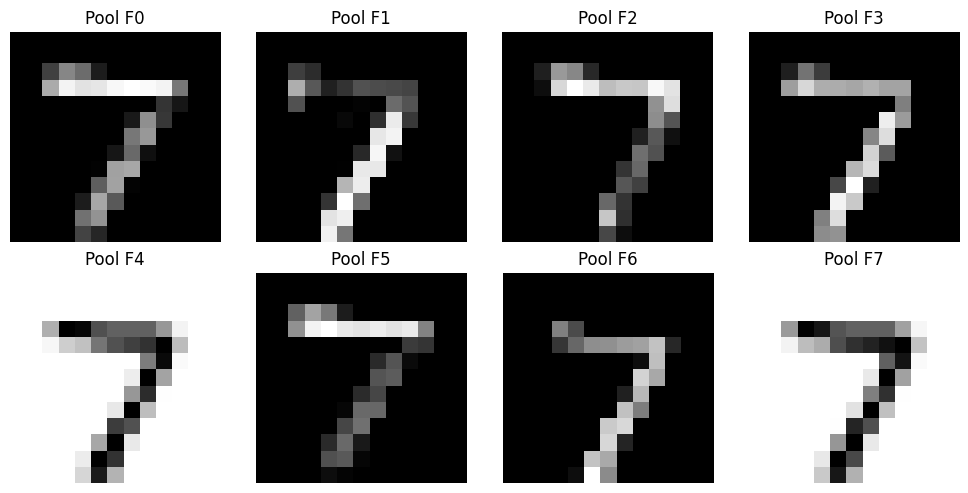

In [14]:
def visualize_feature_maps(image, label):
    # Normal forward steps without softmax
    x = (image / 255.0) - 0.5
    conv_out = conv.forward(x)          # (26, 26, 8)
    relu_out = relu.forward(conv_out)   # (26, 26, 8)
    pool_out = pool.forward(relu_out)   # (13, 13, 8)

    # Show original image
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")
    plt.title(f"Original (label={label})")
    plt.axis("off")
    plt.show()

    # Show conv output feature maps
    plt.figure(figsize=(10, 5))
    for i in range(conv.num_filters):
        plt.subplot(2, 4, i+1)
        plt.imshow(conv_out[:, :, i], cmap="gray")
        plt.title(f"Conv F{i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Show pooled feature maps
    plt.figure(figsize=(10, 5))
    for i in range(conv.num_filters):
        plt.subplot(2, 4, i+1)
        plt.imshow(pool_out[:, :, i], cmap="gray")
        plt.title(f"Pool F{i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Try on the first test image
visualize_feature_maps(test_images[0], test_labels[0])
